#langue Turcique

Encoder Only: Finding the Most Influential Word of an Idiom

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
# Read the CSV file
df = pd.read_csv('turcique.csv')

# Get first idiom
first_idiom = "İki ucu kəsik"

# Filter for first idiom only
df_first = df[df['contains_idioms'] == first_idiom].copy()

# Original texts
df_first['turcique_text'] = df_first['original_text']
df_first['english_text'] = df_first['text']

# Get the individual words from the idiom
idiom_words = first_idiom.split()

# For each word, delete it from the text
for i, word in enumerate(idiom_words):
    df_first[f'turcique_{i+1}stWordDeleted'] = df_first['original_text'].str.replace(
        f' {word}\\b', '', case=False, regex=True
    )

df = df_first

# Verify
print(f"Original text: {df['original_text'].iloc[0]}")
print(f"Word '{idiom_words[0]}' deleted: {df['turcique_1stWordDeleted'].iloc[0]}")
print(f"Word '{idiom_words[1]}' deleted: {df['turcique_2stWordDeleted'].iloc[0]}")
print(f"Word '{idiom_words[2]}' deleted: {df['turcique_3stWordDeleted'].iloc[0]}")

Original text: Choosing between those two jobs is like being iki ucu kəsik.
Word 'İki' deleted: Choosing between those two jobs is like being ucu kəsik.
Word 'ucu' deleted: Choosing between those two jobs is like being iki kəsik.
Word 'kəsik' deleted: Choosing between those two jobs is like being iki ucu.


In [4]:
# Load multilingual embedding model (works well for English and Tr)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
df['idiom_id'] = range(len(df))

# Get all turcique column names (original + deleted versions)
turcique_columns = ['turcique_text'] + [col for col in df.columns if col.startswith('turcique_') and 'Deleted' in col]

# Generate embeddings for all Turcique variations
all_dfs = []

for col in turcique_columns:
    print(f"Generating embeddings for {col}...")
    embeddings = model.encode(df[col].tolist(), show_progress_bar=True)

    temp_df = pd.DataFrame({
        'text': df[col],
        'language': 'Turcique',
        'variation': col,
        'idiom_id': df['idiom_id'],
        'embedding': list(embeddings)
    })
    all_dfs.append(temp_df)

# Generate embeddings for English text
print("Generating English embeddings...")
english_embeddings = model.encode(df['english_text'].tolist(), show_progress_bar=True)

english_df = pd.DataFrame({
    'text': df['english_text'],
    'language': 'English',
    'variation': 'english_text',
    'idiom_id': df['idiom_id'],
    'embedding': list(english_embeddings)
})

all_dfs.append(english_df)

# Combine all DataFrames
combined_df = pd.concat(all_dfs, ignore_index=True)


Generating embeddings for turcique_text...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for turcique_1stWordDeleted...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for turcique_2stWordDeleted...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for turcique_3stWordDeleted...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating English embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
# Reduce embeddings to 2D using UMAP
from umap import UMAP
import numpy as np

print("Reducing embeddings to 2D...")
all_embeddings = np.vstack(combined_df['embedding'].values)
reducer = UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(all_embeddings)

# Add 2D coordinates to dataframe
combined_df['x'] = embeddings_2d[:, 0]
combined_df['y'] = embeddings_2d[:, 1]

# Save to CSV for online visualization
output_df = combined_df[['text', 'language', 'variation', 'idiom_id', 'x', 'y']].copy()
output_df.to_csv('embeddings_2d.csv', index=False)
print("Saved embeddings to 'embeddings_2d.csv'")

# Also save with full embeddings in parquet format
combined_df.to_parquet('embeddings_full.parquet')
print("Saved full embeddings to 'embeddings_full.parquet'")

print(f"\nDataset info: {len(output_df)} points total")
print(f"English: {len(output_df[output_df['language']=='English'])} points")
print(f"Turcique: {len(output_df[output_df['language']=='Turcique'])} points")
print(f"Turcique variations: {output_df[output_df['language']=='Turcique']['variation'].nunique()}")

Reducing embeddings to 2D...
Saved embeddings to 'embeddings_2d.csv'
Saved full embeddings to 'embeddings_full.parquet'

Dataset info: 5 points total
English: 1 points
Turcique: 4 points
Turcique variations: 4


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


In [8]:
import numpy as np
import pandas as pd

# 1. Get English baseline (unchanged)
eng_df = combined_df[combined_df['language'] == 'English'].copy()

# 2. Get all Turcique variations
turcique_variations = combined_df[combined_df['language'] == 'Turcique'].copy()

# 3. Merge English with each Turcique variation
paired_df = pd.merge(
    eng_df[['idiom_id', 'text', 'x', 'y']],
    turcique_variations[['idiom_id', 'text', 'variation', 'x', 'y']],
    on='idiom_id',
    suffixes=('_eng', '_turcique')
)

# 4. Calculate Euclidean distance in 2D UMAP space
paired_df['visual_distance'] = np.sqrt(
    (paired_df['x_eng'] - paired_df['x_turcique'])**2 +
    (paired_df['y_eng'] - paired_df['y_turcique'])**2
)

# 5. Print Statistics per variation
print("=== Distance Statistics by Turcique Variation ===\n")
for variation in paired_df['variation'].unique():
    var_df = paired_df[paired_df['variation'] == variation]
    print(f"{variation}:")
    print(f"  Average distance: {var_df['visual_distance'].mean():.4f}")
    print(f"  Min distance: {var_df['visual_distance'].min():.4f}")
    print(f"  Max distance: {var_df['visual_distance'].max():.4f}\n")

# 6. Find which word deletion causes largest distance change
print("\n=== Most Influential Word (Largest Distance from Original) ===")
baseline_dist = paired_df[paired_df['variation'] == 'turcique_text']['visual_distance'].mean()
for variation in paired_df['variation'].unique():
    if variation != 'turcique_text':
        var_dist = paired_df[paired_df['variation'] == variation]['visual_distance'].mean()
        change = abs(var_dist - baseline_dist)
        print(f"{variation}: Δ = {change:.4f}")

=== Distance Statistics by Turcique Variation ===

turcique_text:
  Average distance: 1.4764
  Min distance: 1.4764
  Max distance: 1.4764

turcique_1stWordDeleted:
  Average distance: 0.9013
  Min distance: 0.9013
  Max distance: 0.9013

turcique_2stWordDeleted:
  Average distance: 1.1339
  Min distance: 1.1339
  Max distance: 1.1339

turcique_3stWordDeleted:
  Average distance: 1.8674
  Min distance: 1.8674
  Max distance: 1.8674


=== Most Influential Word (Largest Distance from Original) ===
turcique_1stWordDeleted: Δ = 0.5751
turcique_2stWordDeleted: Δ = 0.3425
turcique_3stWordDeleted: Δ = 0.3910


/tmp/ipython-input-209962400.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Variation', y='Distance Moyenne', data=df_distances, palette='viridis')
/tmp/ipython-input-209962400.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Variation', y='Delta', data=df_delta, palette='magma')


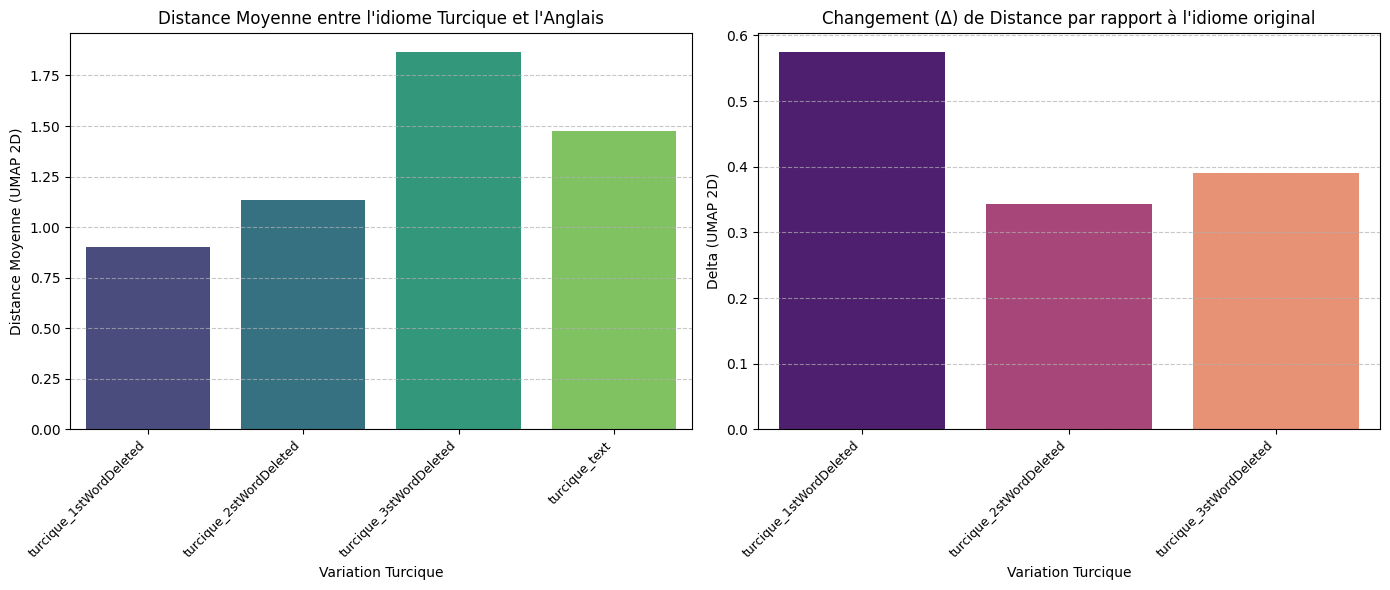

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting distances
distances_data = {
    'Variation': [var for var in paired_df['variation'].unique() if var != 'turcique_text'] + ['turcique_text'],
    'Distance Moyenne': [
        paired_df[paired_df['variation'] == 'turcique_1stWordDeleted']['visual_distance'].mean(),
        paired_df[paired_df['variation'] == 'turcique_2stWordDeleted']['visual_distance'].mean(),
        paired_df[paired_df['variation'] == 'turcique_3stWordDeleted']['visual_distance'].mean(),
        paired_df[paired_df['variation'] == 'turcique_text']['visual_distance'].mean()
    ]
}
df_distances = pd.DataFrame(distances_data)

# Prepare data for plotting delta values
delta_values = {}
baseline_dist = paired_df[paired_df['variation'] == 'turcique_text']['visual_distance'].mean()
for variation in paired_df['variation'].unique():
    if variation != 'turcique_text':
        var_dist = paired_df[paired_df['variation'] == variation]['visual_distance'].mean()
        change = abs(var_dist - baseline_dist)
        delta_values[variation] = change

df_delta = pd.DataFrame(delta_values.items(), columns=['Variation', 'Delta'])

# Create the plots
plt.figure(figsize=(14, 6))

# Plot 1: Average Distances
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Variation', y='Distance Moyenne', data=df_distances, palette='viridis')
plt.title('Distance Moyenne entre l\'idiome Turcique et l\'Anglais', fontsize=12)
plt.xlabel('Variation Turcique', fontsize=10)
plt.ylabel('Distance Moyenne (UMAP 2D)', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Delta (Change from Original Idiom Distance)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Variation', y='Delta', data=df_delta, palette='magma')
plt.title('Changement (Δ) de Distance par rapport à l\'idiome original', fontsize=12)
plt.xlabel('Variation Turcique', fontsize=10)
plt.ylabel('Delta (UMAP 2D)', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ces graphiques visualisent les résultats de l'analyse :

*   **Le graphique de gauche** montre la distance moyenne entre l'idiome turcique (original et ses variations avec un mot supprimé) et sa traduction anglaise dans l'espace UMAP 2D.
    *   On peut voir que la suppression du premier et du deuxième mot (`turcique_1stWordDeleted` et `turcique_2stWordDeleted`) réduit la distance, suggérant une plus grande similarité avec l'anglais que l'idiome original.
    *   Cependant, la suppression du troisième mot (`turcique_3stWordDeleted`) augmente la distance, ce qui indique une plus grande dissimilarité.

*   **Le graphique de droite** illustre le *changement* (Delta) de cette distance par rapport à l'idiome turcique original. Plus le Delta est grand, plus la suppression du mot a eu un impact significatif sur la représentation sémantique de l'idiome.
    *   Le mot `İki` (dans `turcique_1stWordDeleted`) a le plus grand Delta, confirmant qu'il est le mot le plus influent car sa suppression a entraîné le plus grand changement dans la distance sémantique.

In Terminal : embedding-atlas Code3MotPivot/embeddings_full.parquet --x x --y y --text text